# Social Determinants + Geography Exploratory Analysis

This notebook profiles the uploaded Stormont Vail Health files and builds a **patient-level social risk view** using:

- `patients.csv`
- `socdet_clean.csv`
- `tigercensuscodes.csv`

It is intentionally focused on **social determinant concentration, geography, and engagement** because the uploaded files do **not** include `encounters.csv`, so full longitudinal journey reconstruction is not possible yet.

## Questions this notebook answers

1. How much of the patient population was screened in the uploaded social-determinants data?
2. Which domains appear most burdensome?
3. Are there clear demographic or engagement patterns?
4. Which census block groups show the highest concentration of burden?
5. Where are the best follow-up storylines for a presentation or deeper modeling?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)


In [5]:
# File paths
patients_path = "../data/patients.csv"
soc_path = "../data/social_determinants.csv"
tiger_path = "../data/tigercensuscodes.csv"

# Read data
patients = pd.read_csv(patients_path, dtype={"CensusBlockGroupFipsCode": "string"})
soc = pd.read_csv(soc_path)
tiger = pd.read_csv(tiger_path, dtype={"GEOID": "string"})

print("patients:", patients.shape)
print("socdet_clean:", soc.shape)
print("tiger:", tiger.shape)


patients: (947685, 12)
socdet_clean: (3977901, 5)
tiger: (2463, 4)


/var/folders/q9/h9y5zt7j3gzgdgwp42zv3by40000gn/T/ipykernel_86908/3591206574.py:8: DtypeWarning: Columns (0: Domain) have mixed types. Specify dtype option on import or set low_memory=False.
  soc = pd.read_csv(soc_path)


## 1) Quick profiling

In [6]:
print("Unique patients in patients.csv:", patients["DurableKey"].nunique())
print("Unique patients in social determinants file:", soc["PatientDurableKey"].nunique())
print("\nDomain counts:")
display(soc["Domain"].value_counts())
print("\nUnique questions:", soc["DisplayName"].nunique())


Unique patients in patients.csv: 947685
Unique patients in social determinants file: 212357

Domain counts:


Domain
social connections           370222
Alcohol Use                  209058
intimate partner violance    191605
Transportation Needs         164273
Food insecurity              164154
Financial Resource Strain    150323
physical activity            130522
Housing Stability            101048
stress                        70005
Utilities                     66767
Depression                    33728
Name: count, dtype: int64


Unique questions: 32


## 2) Define a simple patient-level risk framework

This is an **exploratory index**, not a clinical score.

We flag a patient as having a domain burden if **any response** suggests difficulty:

- **Transportation Needs**: any “Yes”
- **Housing Stability**: homeless / unstable sleep / moved 2+ times
- **Financial Resource Strain**: trouble paying rent or utilities shutoff threat
- **Utilities hardship**: somewhat hard / hard / very hard paying basics
- **Stress**: rather much / very much
- **Low physical activity**: 0 days of moderate/strenuous exercise

Because the file can contain repeated responses over time, we aggregate to the patient level with **max()** over each domain.


In [7]:
soc2 = soc.copy()
soc2["Domain_norm"] = soc2["Domain"].astype(str).str.strip().str.lower()
soc2["AnswerText"] = soc2["AnswerText"].astype(str).str.strip()
soc2["DisplayName"] = soc2["DisplayName"].astype(str).str.strip()

def risk_flag(question, answer, domain):
    q = str(question).lower()
    a = str(answer).lower()
    d = str(domain).lower()

    if "transportation" in d:
        if a == "yes":
            return 1
        if a == "no":
            return 0
        return np.nan

    if "housing stability" in d:
        if "homeless" in q or "steady place to sleep" in q:
            if a == "yes":
                return 1
            if a == "no":
                return 0
            return np.nan

        if "how many times have you moved" in q or "how many places have you lived" in q:
            try:
                value = float(a.split()[0])
                return 1 if value >= 2 else 0
            except:
                return np.nan

    if "financial resource strain" in d:
        if "mortgage or rent" in q:
            if a == "yes":
                return 1
            if a == "no":
                return 0
            return np.nan

        if "threatened to shut off" in q:
            if a in ["yes", "already shut off"]:
                return 1
            if a == "no":
                return 0
            return np.nan

    if d == "utilities":
        if a in ["somewhat hard", "hard", "very hard"]:
            return 1
        if a in ["not hard at all", "not very hard"]:
            return 0
        return np.nan

    if d == "stress":
        if a in ["rather much", "very much"]:
            return 1
        if a in ["not at all", "only a little", "to some extent"]:
            return 0
        return np.nan

    if d == "physical activity":
        if "how many days per week" in q:
            try:
                days = int(a.split()[0])
                return 1 if days == 0 else 0
            except:
                return np.nan

    return np.nan

soc2["risk_flag"] = soc2.apply(
    lambda r: risk_flag(r["DisplayName"], r["AnswerText"], r["Domain_norm"]),
    axis=1
)
soc2["valid_flag"] = soc2["risk_flag"].notna()

domain_cols = [
    "financial resource strain",
    "housing stability",
    "physical activity",
    "stress",
    "transportation needs",
    "utilities",
]

patient_domain = (
    soc2[soc2["valid_flag"]]
    .groupby(["PatientDurableKey", "Domain_norm"])["risk_flag"]
    .max()
    .unstack()
)

patient_domain = patient_domain.reindex(columns=domain_cols)
patient_domain.head()


Domain_norm,financial resource strain,housing stability,physical activity,stress,transportation needs,utilities
PatientDurableKey,,,,,,
5.0,0.0,0.0,1.0,1.0,0.0,0.0
17.0,0.0,0.0,1.0,0.0,0.0,0.0
62.0,0.0,0.0,0.0,1.0,0.0,1.0
102.0,0.0,NaN,NaN,0.0,0.0,0.0
168.0,0.0,0.0,1.0,0.0,0.0,1.0


In [8]:
full = patients.merge(
    patient_domain.reset_index().rename(columns={"PatientDurableKey": "DurableKey"}),
    on="DurableKey",
    how="left"
)

full["screened_any"] = full[domain_cols].notna().any(axis=1)
full["risk_count"] = full[domain_cols].fillna(0).sum(axis=1)

full["geoid"] = full["CensusBlockGroupFipsCode"].astype("string")
bad_geo = full["geoid"].isin(["*Unspecified", "Unspecified", "Unknown", "*Unknown"]) | full["geoid"].isna()
full.loc[bad_geo, "geoid"] = pd.NA

print("Total patients:", len(full))
print("Patients with any usable social-risk signal:", int(full["screened_any"].sum()))
print("Screened share:", round(full["screened_any"].mean() * 100, 2), "%")
print("Patients with usable GEOID:", int(full["geoid"].notna().sum()))


Total patients: 947685
Patients with any usable social-risk signal: 64519
Screened share: 6.81 %
Patients with usable GEOID: 336514


## 3) Domain prevalence among screened patients

,n_answered,n_flagged,pct_flagged_among_answered
physical activity,52063,17907.0,0.343949
stress,53742,8877.0,0.165178
utilities,52172,7387.0,0.141589
financial resource strain,58300,4422.0,0.075849
housing stability,36316,2400.0,0.066087
transportation needs,59143,3027.0,0.051181


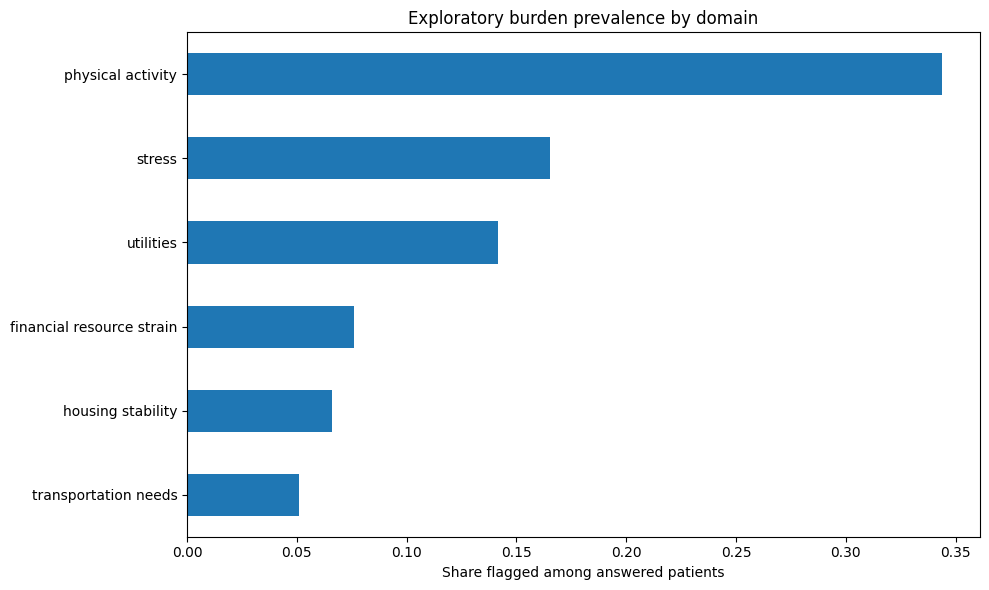

In [9]:
screened = full[full["screened_any"]].copy()

domain_summary = pd.DataFrame({
    "n_answered": [screened[c].notna().sum() for c in domain_cols],
    "n_flagged": [screened[c].fillna(0).sum() for c in domain_cols],
    "pct_flagged_among_answered": [
        screened.loc[screened[c].notna(), c].mean() for c in domain_cols
    ]
}, index=domain_cols).sort_values("pct_flagged_among_answered", ascending=False)

display(domain_summary)

ax = domain_summary["pct_flagged_among_answered"].sort_values().plot(kind="barh")
ax.set_xlabel("Share flagged among answered patients")
ax.set_title("Exploratory burden prevalence by domain")
plt.tight_layout()
plt.show()


## 4) How many burdens stack on the same patient?

risk_count
0.0    36740
1.0    18415
2.0     5436
3.0     2120
4.0      974
5.0      527
6.0      307
Name: count, dtype: int64

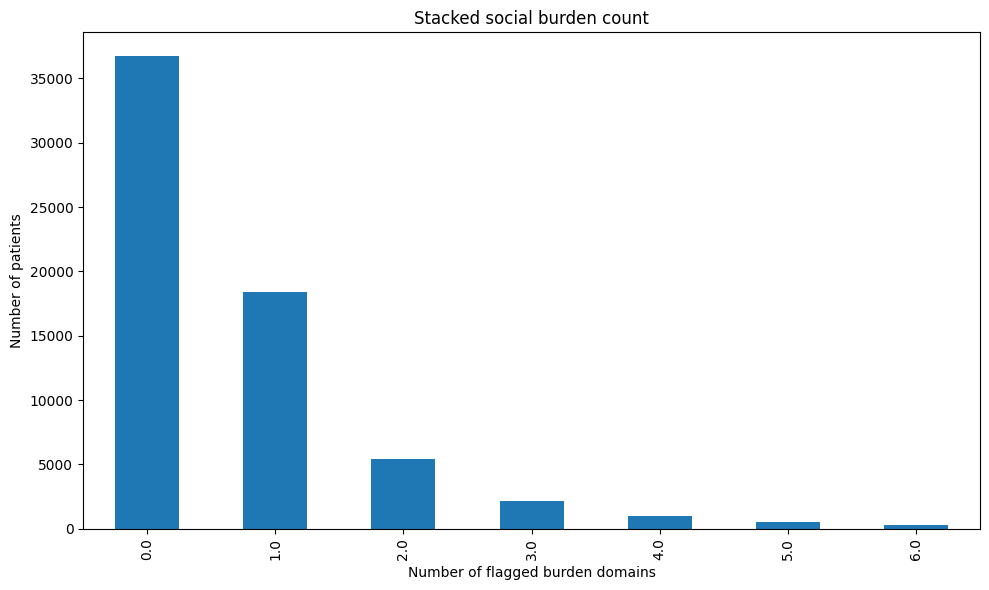

In [10]:
risk_dist = screened["risk_count"].value_counts().sort_index()
display(risk_dist)

ax = risk_dist.plot(kind="bar")
ax.set_xlabel("Number of flagged burden domains")
ax.set_ylabel("Number of patients")
ax.set_title("Stacked social burden count")
plt.tight_layout()
plt.show()


## 5) MyChart engagement vs social burden

This is interesting because MyChart can act as a rough proxy for how connected or reachable a patient is within the SVH ecosystem.


,n,avg_risk_count,pct_transport,pct_financial,pct_utilities
MyChartStatus,,,,,
Activated,54313,0.613960,0.040281,0.066847,0.130937
Pending Activation,6544,1.043399,0.112688,0.137765,0.221990
Inactivated,2374,0.983993,0.088771,0.085753,0.149528
Patient Declined,1120,1.250893,0.146110,0.149038,0.230681
*Unspecified,98,0.826531,0.042105,0.085366,0.144444
Non Standard MyChart Status,69,0.391304,0.044776,0.030769,0.083333
"Activation Code Generated, but Disabled",1,1.000000,0.000000,0.000000,0.000000


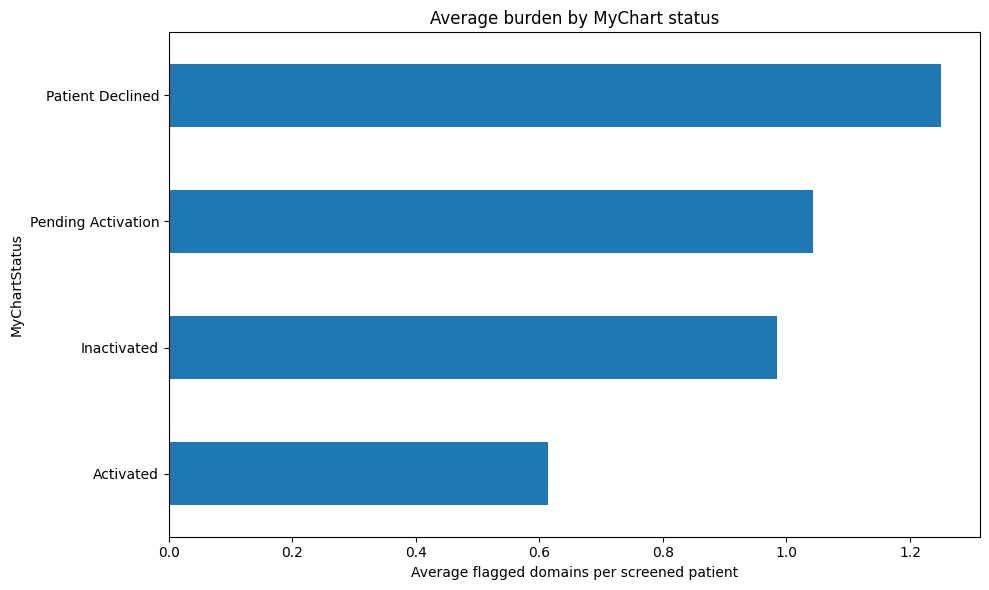

In [11]:
mychart_summary = (
    screened.groupby("MyChartStatus")
    .agg(
        n=("DurableKey", "size"),
        avg_risk_count=("risk_count", "mean"),
        pct_transport=("transportation needs", lambda s: s.dropna().mean() if s.notna().any() else np.nan),
        pct_financial=("financial resource strain", lambda s: s.dropna().mean() if s.notna().any() else np.nan),
        pct_utilities=("utilities", lambda s: s.dropna().mean() if s.notna().any() else np.nan),
    )
    .sort_values("n", ascending=False)
)

display(mychart_summary)

plot_df = mychart_summary[mychart_summary["n"] >= 100].sort_values("avg_risk_count")
ax = plot_df["avg_risk_count"].plot(kind="barh")
ax.set_xlabel("Average flagged domains per screened patient")
ax.set_title("Average burden by MyChart status")
plt.tight_layout()
plt.show()


## 6) Birth-year-bin patterns

,n,avg_risk_count,pct_transport,pct_housing,pct_stress
PatientBirthYearBin,,,,,
1930.0,837,0.634409,0.023004,0.010432,0.034954
1935.0,1992,0.593373,0.025641,0.010471,0.058824
1940.0,3406,0.562537,0.026889,0.011326,0.065318
1945.0,5327,0.485451,0.024000,0.010584,0.071054
1950.0,6854,0.474176,0.027101,0.012557,0.074309
1955.0,6984,0.544387,0.041269,0.026554,0.098229
1960.0,5578,0.672463,0.054605,0.044693,0.141161
1965.0,4246,0.756712,0.060845,0.065615,0.173341
1970.0,3852,0.811526,0.066891,0.083333,0.215086


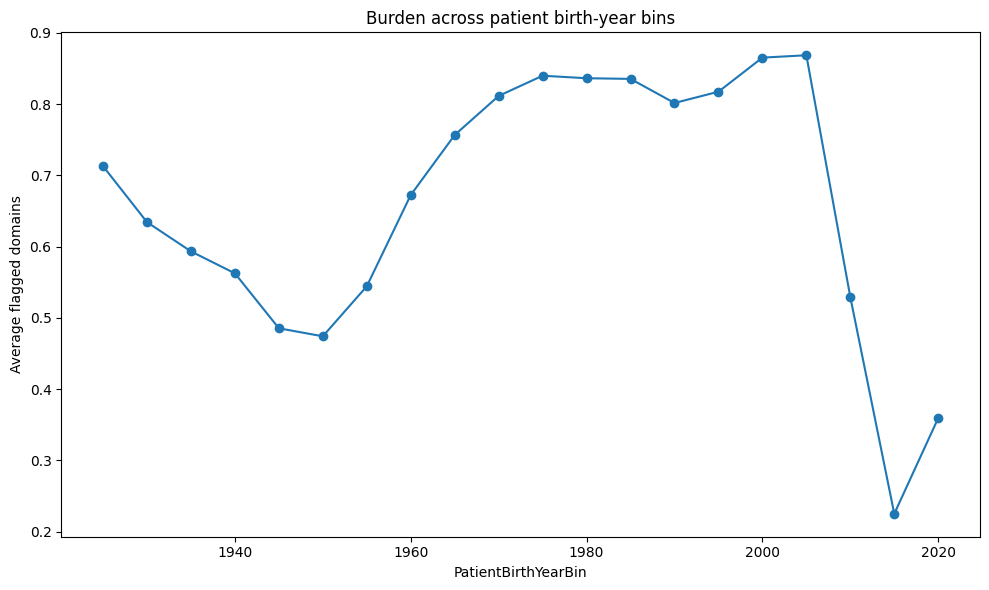

In [12]:
age_summary = (
    screened.groupby("PatientBirthYearBin")
    .agg(
        n=("DurableKey", "size"),
        avg_risk_count=("risk_count", "mean"),
        pct_transport=("transportation needs", lambda s: s.dropna().mean() if s.notna().any() else np.nan),
        pct_housing=("housing stability", lambda s: s.dropna().mean() if s.notna().any() else np.nan),
        pct_stress=("stress", lambda s: s.dropna().mean() if s.notna().any() else np.nan),
    )
    .sort_index()
)

display(age_summary.tail(20))

plot_age = age_summary[age_summary["n"] >= 200]

ax = plot_age["avg_risk_count"].plot(marker="o")
ax.set_ylabel("Average flagged domains")
ax.set_title("Burden across patient birth-year bins")
plt.tight_layout()
plt.show()


## 7) Geography: where is burden concentrated?

We aggregate to block group (`GEOID`) and keep only block groups with at least 25 screened patients to avoid noisy small-cell comparisons.


,geoid,screened_patients,avg_risk_count,pct_transport,pct_housing,pct_financial,pct_utilities,PopulationValue,CENTLAT,CENTLON,screened_per_1000_pop
648,201770008004,89,2.325843,0.365854,0.426667,0.464286,0.452055,861.0,39.066591,-95.663882,103.368177
769,201770040004,59,1.542373,0.228070,0.250000,0.192308,0.387755,346.0,39.042034,-95.681287,170.520231
634,201770004002,61,1.540984,0.152542,0.140000,0.258621,0.415094,988.0,39.039643,-95.694251,61.740891
726,201770031002,130,1.500000,0.208333,0.102804,0.252101,0.400000,1210.0,39.038987,-95.644925,107.438017
642,201770006003,68,1.485294,0.191176,0.169811,0.174603,0.301587,560.0,39.056519,-95.689267,121.428571
637,201770005001,76,1.460526,0.114286,0.148148,0.281690,0.400000,766.0,39.050903,-95.685572,99.216710
203,200610001003,54,1.444444,0.169811,0.208333,0.250000,0.340909,524.0,39.042704,-96.823275,103.053435
218,200610005002,54,1.407407,0.220000,0.133333,0.212766,0.272727,661.0,39.021022,-96.824568,81.694402
646,201770008002,99,1.404040,0.159574,0.153846,0.161290,0.373494,756.0,39.077647,-95.657279,130.952381
635,201770004003,105,1.400000,0.210000,0.164706,0.247423,0.400000,1102.0,39.039830,-95.688099,95.281307


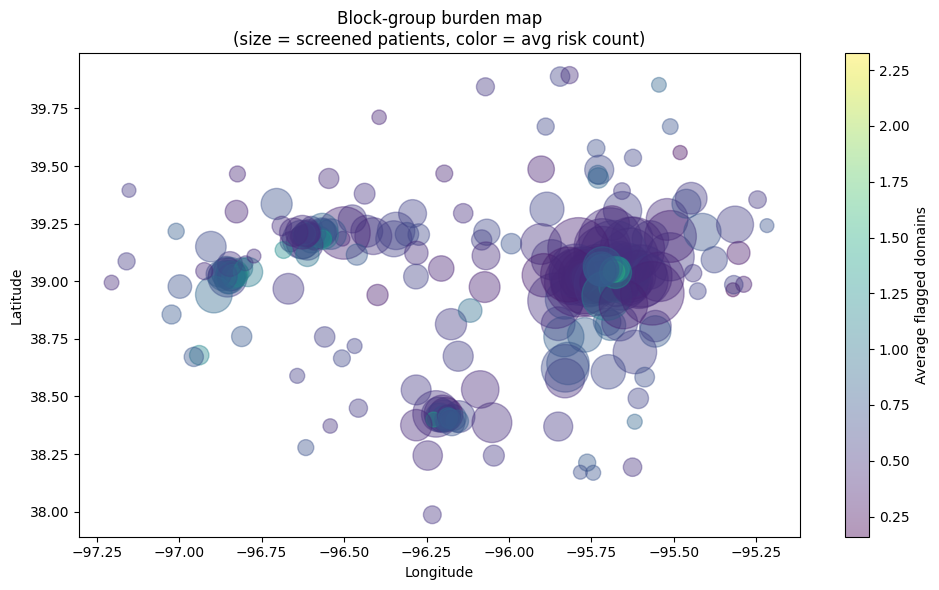

In [15]:
geo_summary = (
    screened[screened["geoid"].notna()]
    .groupby("geoid")
    .agg(
        screened_patients=("DurableKey", "nunique"),
        avg_risk_count=("risk_count", "mean"),
        pct_transport=("transportation needs", lambda s: s.dropna().mean() if s.notna().any() else np.nan),
        pct_housing=("housing stability", lambda s: s.dropna().mean() if s.notna().any() else np.nan),
        pct_financial=("financial resource strain", lambda s: s.dropna().mean() if s.notna().any() else np.nan),
        pct_utilities=("utilities", lambda s: s.dropna().mean() if s.notna().any() else np.nan),
    )
    .reset_index()
)

geo_summary = geo_summary.merge(
    tiger.rename(columns={"GEOID": "geoid"}),
    on="geoid",
    how="left"
)

geo_summary["screened_per_1000_pop"] = (
    geo_summary["screened_patients"] / geo_summary["PopulationValue"] * 1000
)

geo25 = geo_summary[geo_summary["screened_patients"] >= 25].copy()

display(
    geo25.sort_values("avg_risk_count", ascending=False).head(15)
)

fig, ax = plt.subplots()
sc = ax.scatter(
    geo25["CENTLON"],
    geo25["CENTLAT"],
    alpha=0.4,
    s=geo25["screened_patients"] * 4,
    c=geo25["avg_risk_count"]
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Block-group burden map\n(size = screened patients, color = avg risk count)")
plt.colorbar(sc, ax=ax, label="Average flagged domains")
plt.tight_layout()
plt.show()


## 8) Summary

This exploratory analysis focused on social determinant burden, geographic concentration, and patient engagement patterns rather than full longitudinal patient journeys. A true journey analysis would require the encounters table, since the challenge defines a patient journey as a sequence of encounters linked by a common diagnosis, ideally tracked using DiagnosisValue.

### Key findings from the analysis:

The social determinants data reflects only a screened subset of patients, not the full patient population. The documentation notes that screening was rolled out gradually, first in hospital admissions and then expanded, and that providers may ask only selected questions.
Out of roughly 947,685 patients in the patient file, about 64,519 patients appeared in the cleaned social-determinants analysis, or about 6.8% of the full patient population. The patients file itself is documented as containing 947,685 rows.
The most prominent burden domains in the screened group were:

- Physical activity: 34.39%
- Stress: 16.52%
- Utilities hardship: 14.16%
- Financial strain: 7.58%
- Housing instability: 6.61%
- Transportation needs: 5.12%

Social burden often stacked across domains rather than appearing in isolation. About 14.51% of screened patients had 2 or more flagged domains, suggesting that many patients face overlapping rather than single hardships.
Burden was also geographically concentrated. Some census block groups showed noticeably higher average burden than others, which supports a place-based interpretation of social risk. The readme notes that patient location is given by CensusBlockGroupFipsCode, while also warning that blocks with fewer than 11 patients are coded as *Unspecified, which can under-represent rural areas.
Patient engagement may also matter. The readme explains that MyChartStatus can help indicate a patient’s engagement with SVH. In the analysis, patients with weaker MyChart activation status tended to show higher average social burden.
### Takeaways
Social risk is concentrated, not random. It is clustered in a relatively small screened subset of patients and in certain geographic areas.
Transportation is important, but not the only story. Stress, utilities hardship, and physical inactivity appeared even more frequently in this screened group.

Many patients face multiple barriers at once. The overlap across domains suggests that patient hardship is often multidimensional.
Geography matters. Some census block groups appear to carry much higher social burden than others, making mapping and neighborhood-level analysis especially valuable.

Engagement may be part of the picture. Lower MyChart activation appears to coincide with higher burden, which may have implications for follow-up care and continuity.

The strongest next step is journey linkage. Adding encounters.csv would allow this social determinant analysis to be connected directly to patient journey outcomes such as gaps in care, repeated visits, and fragmented treatment paths.